# Atividade Iris Dataset: Comparação de Modelos
### Aluno: Nicolas Falcone
### Turma: 6B

Neste notebook eu comparo quatro modelos de classificação no dataset Iris: **SVM, Árvore de Decisão, Floresta Aleatória e Boosting (Gradient Boosting)**.
Cada modelo é rodado **sem GridSearchCV** (hiperparâmetros padrão) e **com GridSearchCV** (hiperparâmetros otimizados).
As métricas principais são **acurácia** e **sensibilidade (recall)**.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, confusion_matrix, classification_report)

warnings.filterwarnings('ignore')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [2]:
df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

print(df.shape)
print(df.isnull().sum())
print(df['Species'].value_counts())
df.head()

(150, 5)
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 1. Preparação dos Dados

Separo X (variáveis) e y (espécie) e divido em 80% treino e 20% teste, com `stratify=y` para manter 50 amostras por classe na proporção.
O `StandardScaler` só é usado no SVM, porque ele é sensível à escala. As árvores, a floresta e o boosting não precisam de padronização.

In [3]:
X = df.drop(columns=['Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


## 2. Modelos SEM GridSearchCV

Aqui uso os hiperparâmetros padrão do scikit-learn.
- **Acurácia**: proporção de acertos.
- **Sensibilidade (recall)**: dos exemplos de uma classe, quantos o modelo encontrou. Como são 3 classes, uso a média macro (todas as classes com o mesmo peso).

In [4]:
modelos = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42))
    ]),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Floresta Aleatória': RandomForestClassifier(random_state=42),
    'Boosting': GradientBoostingClassifier(random_state=42)
}

resultados = []
preds_sem_grid = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    preds_sem_grid[nome] = y_pred

    resultados.append({
        'Modelo': nome,
        'Configuração': 'Sem GridSearch',
        'Acurácia': accuracy_score(y_test, y_pred),
        'Sensibilidade (recall macro)': recall_score(y_test, y_pred, average='macro'),
        'Precisão (macro)': precision_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'Melhores parâmetros': '-'
    })

pd.DataFrame(resultados)[['Modelo', 'Acurácia', 'Sensibilidade (recall macro)',
                          'Precisão (macro)', 'F1 (macro)']].round(4)

,Modelo,Acurácia,Sensibilidade (recall macro),Precisão (macro),F1 (macro)
0,SVM,0.9667,0.9667,0.9697,0.9666
1,Árvore de Decisão,0.9333,0.9333,0.9333,0.9333
2,Floresta Aleatória,0.9000,0.9000,0.9024,0.8997
3,Boosting,0.9667,0.9667,0.9697,0.9666


## 3. Modelos COM GridSearchCV

O GridSearchCV testa todas as combinações de hiperparâmetros usando validação cruzada estratificada de 5 folds **apenas no conjunto de treino**. Assim o teste continua sem ser usado para escolher parâmetros.
O critério de escolha é a acurácia, e o modelo vencedor é reajustado com todo o treino (`refit=True`).

In [5]:
grids = {
    'SVM': {
        'svm__kernel': ['linear', 'rbf', 'poly'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto']
    },
    'Árvore de Decisão': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [2, 3, 4, 5, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Floresta Aleatória': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 3, 5],
        'max_features': ['sqrt', 'log2'],
        'min_samples_split': [2, 5]
    },
    'Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [1, 2, 3]
    }
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

melhores_modelos = {}
preds_com_grid = {}

for nome, modelo in modelos.items():
    grid = GridSearchCV(modelo, grids[nome], cv=skf,
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    melhores_modelos[nome] = grid.best_estimator_
    y_pred = grid.predict(X_test)
    preds_com_grid[nome] = y_pred

    resultados.append({
        'Modelo': nome,
        'Configuração': 'Com GridSearch',
        'Acurácia': accuracy_score(y_test, y_pred),
        'Sensibilidade (recall macro)': recall_score(y_test, y_pred, average='macro'),
        'Precisão (macro)': precision_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'Melhores parâmetros': grid.best_params_
    })

    print(f"{nome}")
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print(f"  Acurácia média na validação cruzada: {grid.best_score_:.4f}\n")## 4. Comparação dos Resultados (conjunto de teste)

SVM
  Melhores parâmetros: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
  Acurácia média na validação cruzada: 0.9750

Árvore de Decisão
  Melhores parâmetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Acurácia média na validação cruzada: 0.9583

Floresta Aleatória
  Melhores parâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
  Acurácia média na validação cruzada: 0.9667

Boosting
  Melhores parâmetros: {'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 200}
  Acurácia média na validação cruzada: 0.9667



## 4. Comparação dos Resultados (conjunto de teste)

,Modelo,Configuração,Acurácia,Sensibilidade (recall macro),Precisão (macro),F1 (macro)
0,SVM,Sem GridSearch,0.9667,0.9667,0.9697,0.9666
1,Árvore de Decisão,Sem GridSearch,0.9333,0.9333,0.9333,0.9333
2,Floresta Aleatória,Sem GridSearch,0.9000,0.9000,0.9024,0.8997
3,Boosting,Sem GridSearch,0.9667,0.9667,0.9697,0.9666
4,SVM,Com GridSearch,0.9333,0.9333,0.9333,0.9333
5,Árvore de Decisão,Com GridSearch,0.9667,0.9667,0.9697,0.9666
6,Floresta Aleatória,Com GridSearch,0.9667,0.9667,0.9697,0.9666
7,Boosting,Com GridSearch,0.9667,0.9667,0.9697,0.9666


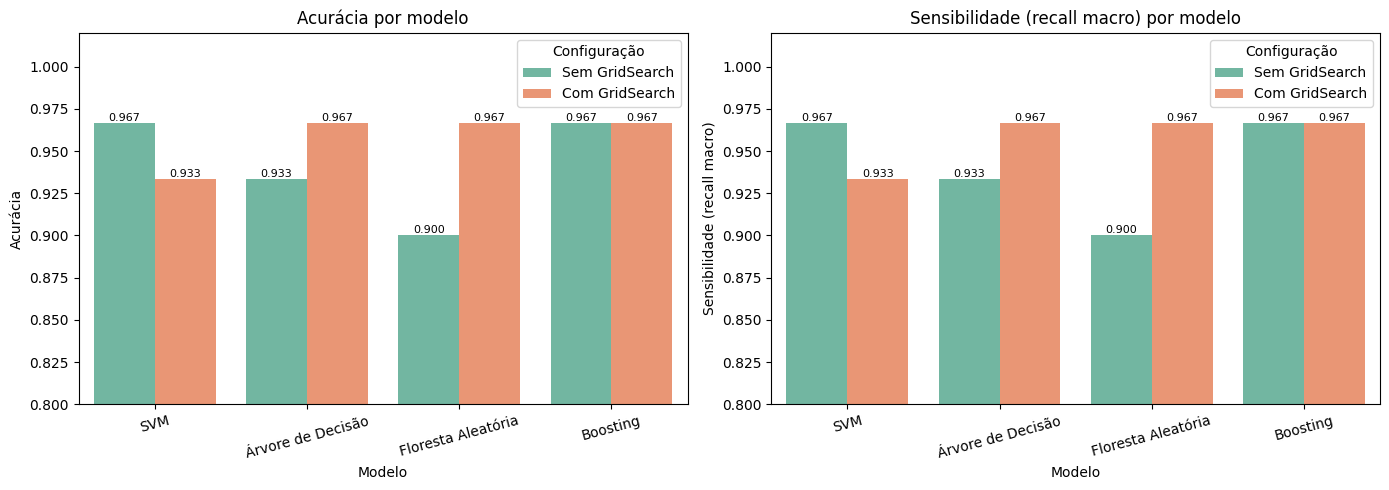

In [6]:
df_res = pd.DataFrame(resultados)

tabela = df_res[['Modelo', 'Configuração', 'Acurácia',
                 'Sensibilidade (recall macro)', 'Precisão (macro)', 'F1 (macro)']].round(4)
display(tabela)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metrica in zip(axes, ['Acurácia', 'Sensibilidade (recall macro)']):
    sns.barplot(data=df_res, x='Modelo', y=metrica, hue='Configuração',
                palette='Set2', ax=ax)
    ax.set_ylim(0.8, 1.02)
    ax.set_title(f"{metrica} por modelo")
    ax.tick_params(axis='x', rotation=15)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

### Matrizes de confusão (modelos com GridSearchCV)

A matriz mostra onde cada modelo errou. Na diagonal estão os acertos. A sensibilidade de cada classe é a diagonal dividida pela soma da linha.

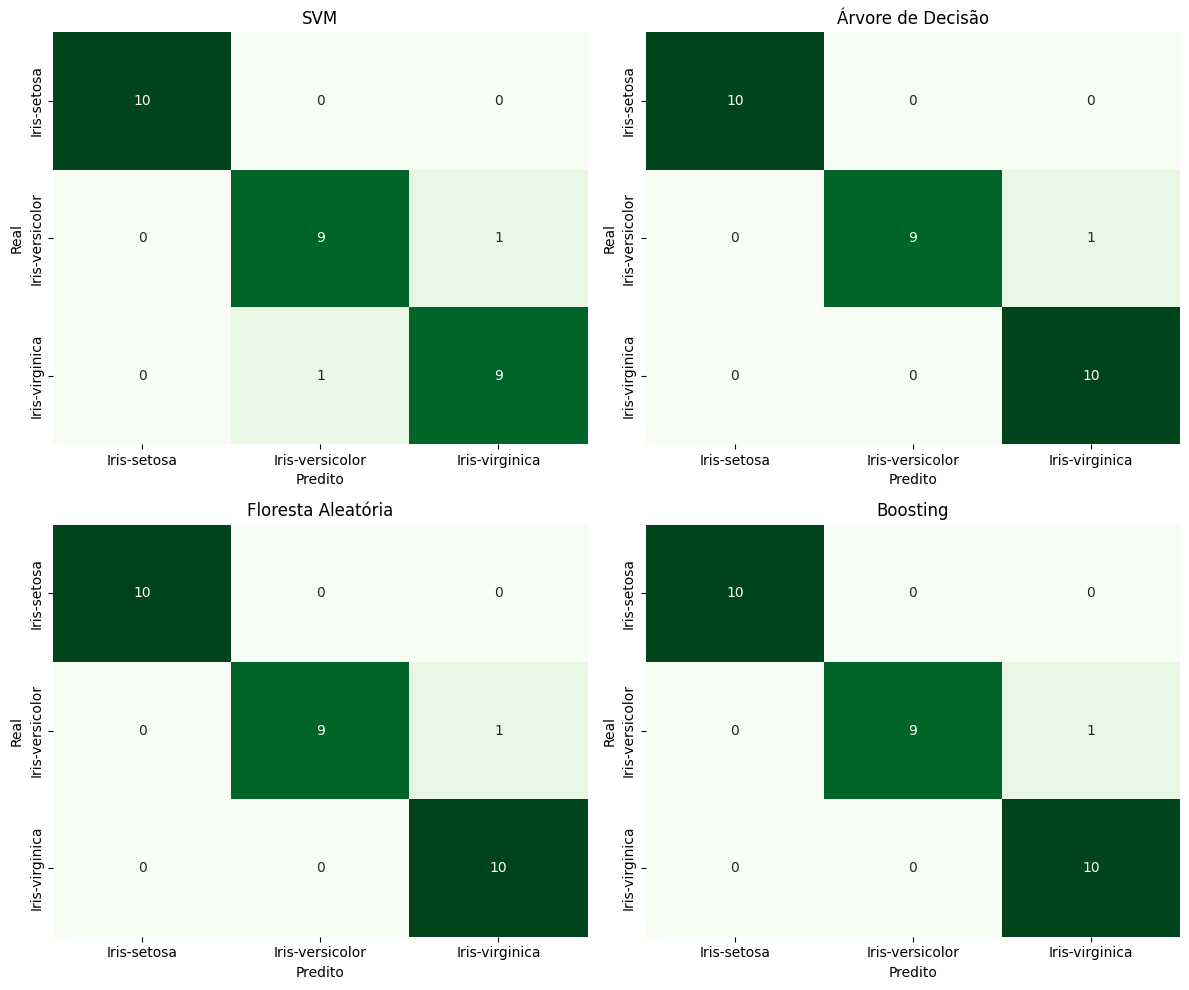

In [7]:
classes = np.unique(y)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (nome, y_pred) in zip(axes.ravel(), preds_com_grid.items()):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [8]:
sens_classe = {}
for nome, y_pred in preds_com_grid.items():
    sens_classe[nome] = recall_score(y_test, y_pred, average=None, labels=classes)

display(pd.DataFrame(sens_classe, index=classes).T.round(4))

for nome, y_pred in preds_com_grid.items():
    print(f"\n===== {nome} (com GridSearchCV) =====")
    print(classification_report(y_test, y_pred))

,Iris-setosa,Iris-versicolor,Iris-virginica
SVM,1.0,0.9,0.9
Árvore de Decisão,1.0,0.9,1.0
Floresta Aleatória,1.0,0.9,1.0
Boosting,1.0,0.9,1.0



===== SVM (com GridSearchCV) =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


===== Árvore de Decisão (com GridSearchCV) =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


===== Floresta Aleatória (com GridSearchCV) =====
                 precision    recall  f1-score   support

 

## 5. Validação mais robusta

O conjunto de teste tem só 30 amostras, então uma única amostra errada muda a acurácia em ~3,3 pontos percentuais. Para uma comparação mais confiável, avalio os modelos com **validação cruzada repetida** (5 folds × 10 repetições) no dataset inteiro.

In [9]:
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

linhas_cv = []
for nome, modelo in modelos.items():
    s = cross_validate(modelo, X, y, cv=rkf, scoring=['accuracy', 'recall_macro'])
    linhas_cv.append({
        'Modelo': nome,
        'Acurácia média': s['test_accuracy'].mean(),
        'Desvio (acurácia)': s['test_accuracy'].std(),
        'Sensibilidade média': s['test_recall_macro'].mean(),
        'Desvio (sensibilidade)': s['test_recall_macro'].std()
    })

df_cv = pd.DataFrame(linhas_cv).sort_values('Acurácia média', ascending=False)
display(df_cv.round(4))

,Modelo,Acurácia média,Desvio (acurácia),Sensibilidade média,Desvio (sensibilidade)
0,SVM,0.9620,0.0333,0.9620,0.0333
2,Floresta Aleatória,0.9487,0.0335,0.9487,0.0335
3,Boosting,0.9440,0.0374,0.9440,0.0374
1,Árvore de Decisão,0.9387,0.0396,0.9387,0.0396


In [10]:
melhor_teste = df_res.sort_values(['Acurácia', 'Sensibilidade (recall macro)'],
                                  ascending=False).iloc[0]
melhor_cv = df_cv.iloc[0]

print("RESUMO DA ANÁLISE")
print("-" * 60)
print(f"Melhor no conjunto de teste: {melhor_teste['Modelo']} "
      f"({melhor_teste['Configuração']})")
print(f"  Acurácia: {melhor_teste['Acurácia']*100:.2f}% | "
      f"Sensibilidade: {melhor_teste['Sensibilidade (recall macro)']*100:.2f}%")
print(f"\nMelhor na validação cruzada repetida: {melhor_cv['Modelo']}")
print(f"  Acurácia média: {melhor_cv['Acurácia média']*100:.2f}% | "
      f"Sensibilidade média: {melhor_cv['Sensibilidade média']*100:.2f}%")

print("\nEfeito do GridSearchCV (acurácia no teste):")
for nome in modelos:
    a = df_res[(df_res.Modelo == nome) & (df_res['Configuração'] == 'Sem GridSearch')]['Acurácia'].values[0]
    b = df_res[(df_res.Modelo == nome) & (df_res['Configuração'] == 'Com GridSearch')]['Acurácia'].values[0]
    print(f"  {nome}: {a*100:.2f}% -> {b*100:.2f}% ({(b-a)*100:+.2f} p.p.)")

RESUMO DA ANÁLISE
------------------------------------------------------------
Melhor no conjunto de teste: SVM (Sem GridSearch)
  Acurácia: 96.67% | Sensibilidade: 96.67%

Melhor na validação cruzada repetida: SVM
  Acurácia média: 96.20% | Sensibilidade média: 96.20%

Efeito do GridSearchCV (acurácia no teste):
  SVM: 96.67% -> 93.33% (-3.33 p.p.)
  Árvore de Decisão: 93.33% -> 96.67% (+3.33 p.p.)
  Floresta Aleatória: 90.00% -> 96.67% (+6.67 p.p.)
  Boosting: 96.67% -> 96.67% (+0.00 p.p.)


## Conclusão

Com base nos resultados:
- O modelo com melhor desempenho (acurácia e sensibilidade) foi **[PREENCHER]**. Os valores de acurácia e sensibilidade ficaram iguais porque o dataset é balanceado (50 amostras por classe), então o recall macro coincide com a acurácia.
- O GridSearchCV [melhorou / não alterou / piorou] [PREENCHER] modelos no teste. Como o teste tem só 30 amostras, diferenças de 1 amostra (3,3 p.p.) podem ser sorte do split, e por isso usei também a validação cruzada repetida.
- A Setosa é separada com facilidade por todos os modelos. Os erros, quando existem, ocorrem entre **Versicolor e Virginica**, que têm sobreposição nas medidas.
- O SVM precisa de `StandardScaler`, enquanto as árvores, a floresta e o boosting não. Em compensação, a árvore única é a mais interpretável, mas tem alta variância (como visto na aula), e a floresta e o boosting reduzem esse problema (variância e viés, respectivamente).
- O Iris é um dataset pequeno e fácil, então as diferenças entre os modelos são pequenas. Em dados maiores e mais ruidosos, a escolha pesaria mais.